In [11]:
import numpy as np
import torch
from torch import nn
import tqdm

In [12]:
import torchvision
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import train_test_split

In [13]:
# Load and normalize the dataset for training and testing
# It will download the dataset into data subfolder (change to your data folder name)
torch.manual_seed(1)
np.random.seed(1)
train_dataset = torchvision.datasets.FashionMNIST('data/', train=True, download=True,
                             transform=torchvision.transforms.Compose([
                               torchvision.transforms.ToTensor(),
                               torchvision.transforms.Normalize(
                                 (0.2860,), (0.3530,))
                             ]))

test_dataset = torchvision.datasets.FashionMNIST('data/', train=False, download=True,
                             transform=torchvision.transforms.Compose([
                               torchvision.transforms.ToTensor(),
                               torchvision.transforms.Normalize(
                                 (0.2860,), (0.3530,))
                             ]))


# Create a validation set of 10%
train_indices, val_indices, _, _ = train_test_split(
    range(len(train_dataset)),
    train_dataset.targets,
    stratify=train_dataset.targets,
    test_size=0.1,
)

# Generate training and validation subsets based on indices
train_split = Subset(train_dataset, train_indices)
val_split = Subset(train_dataset, val_indices)


# Set batch sizes
train_batch_size = 512
test_batch_size  = 256

train_batches = DataLoader(train_split, batch_size=train_batch_size, shuffle=True)
val_batches = DataLoader(val_split, batch_size=train_batch_size, shuffle=True)
test_batches = DataLoader(test_dataset, batch_size=test_batch_size, shuffle=True)

num_train_batches = len(train_batches)
num_val_batches   = len(val_batches)
num_test_batches  = len(test_batches)

print(f'Train batches : {num_train_batches}')
print(f'Val batches   : {num_val_batches}')
print(f'Test batches  : {num_test_batches}')

Train batches : 106
Val batches   : 12
Test batches  : 40


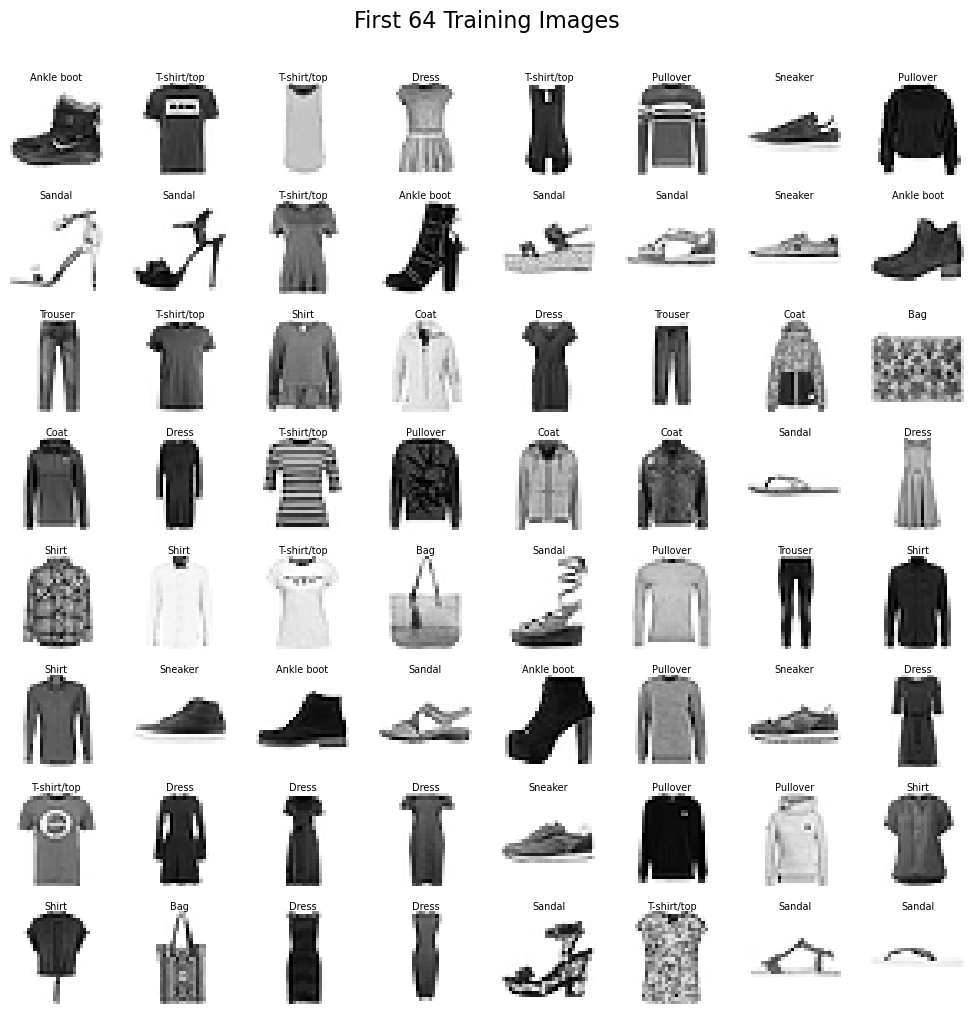

In [14]:
# Visualize the first 64 training images
CLASS_NAMES = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
]

def plot_images(XX, labels, N, title):
    fig, ax = plt.subplots(N, N, figsize=(10, 10))
    for i in range(N):
        for j in range(N):
            idx = N * i + j
            ax[i, j].imshow(XX[idx], cmap='Greys')
            ax[i, j].set_title(CLASS_NAMES[labels[idx].item()], fontsize=7, pad=2)
            ax[i, j].axis('off')
    fig.suptitle(title, fontsize=16, y=1.01)
    plt.tight_layout()
    plt.show()

plot_images(train_dataset.data[:64], train_dataset.targets[:64], 8, 'First 64 Training Images')

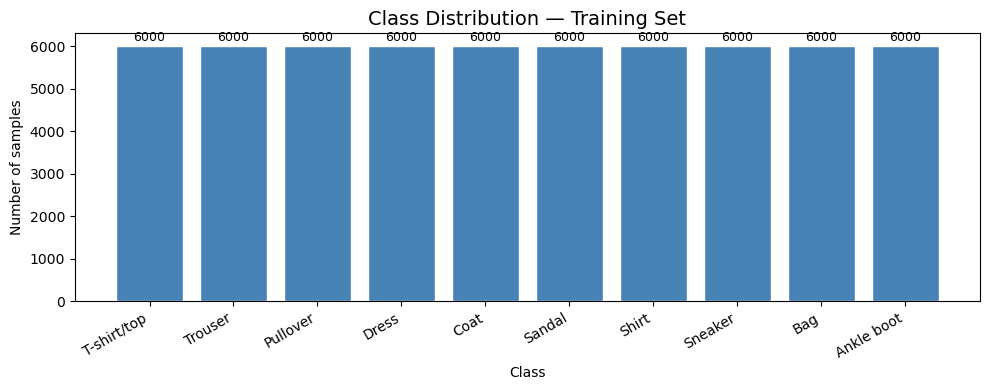

In [15]:
# Class distribution in the training set
counts = [(train_dataset.targets == i).sum().item() for i in range(10)]

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(CLASS_NAMES, counts, color='steelblue', edgecolor='white')
ax.set_title('Class Distribution — Training Set', fontsize=14)
ax.set_ylabel('Number of samples')
ax.set_xlabel('Class')
plt.xticks(rotation=30, ha='right')
for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 50,
            str(count), ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

In [16]:
# Fully Connected Neural Network
class Network(nn.Module):
    def __init__(self, input_dim, output_dim, hidden_layers=2, hidden_neurons=256, batch_norm=False):
        super(Network, self).__init__()

        layers = [input_dim] + [hidden_neurons] * hidden_layers + [output_dim]
        self.fc_layers = nn.ModuleList(
            [nn.Linear(layers[i], layers[i+1]) for i in range(len(layers)-1)]
        )
        self.relu = nn.ReLU()
        self.batch_norm = batch_norm
        if batch_norm:
            self.bn_layers = nn.ModuleList(
                [nn.BatchNorm1d(hidden_neurons) for j in range(hidden_layers)]
            )

    def forward(self, x):
        for i, layer in enumerate(self.fc_layers[:-1]):
            x = layer(x)
            if self.batch_norm:
                x = self.bn_layers[i](x)
            x = self.relu(x)
        return self.fc_layers[-1](x)

In [17]:
# Training and evaluation function — supports SGD, RMSprop, and Adam
def train_and_evaluate(optimizer_name, lr, init_method='kaiming', batch_norm=False,
                        epochs=40, hidden_layers=2, hidden_neurons=512):
    torch.manual_seed(1)
    np.random.seed(1)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    model = Network(input_dim=784, output_dim=10, hidden_layers=hidden_layers,
                    hidden_neurons=hidden_neurons, batch_norm=batch_norm).to(device)

    for layer in model.fc_layers:
        if init_method == 'xavier':
            nn.init.xavier_normal_(layer.weight)
        elif init_method == 'random_normal':
            nn.init.normal_(layer.weight)
        elif init_method == 'kaiming':
            nn.init.kaiming_uniform_(layer.weight, nonlinearity='relu')
        nn.init.zeros_(layer.bias)

    train_loss_list = np.zeros((epochs,))
    validation_accuracy_list = np.zeros((epochs,))
    loss_func = torch.nn.CrossEntropyLoss()

    if optimizer_name == 'SGD':
        optimizer = torch.optim.SGD(params=model.parameters(), lr=lr)
    elif optimizer_name == 'RMSprop':
        optimizer = torch.optim.RMSprop(params=model.parameters(), lr=lr)
    elif optimizer_name == 'Adam':
        optimizer = torch.optim.Adam(params=model.parameters(), lr=lr)

    for epoch in tqdm.trange(epochs, desc=f'{optimizer_name} lr={lr} init={init_method} bn={batch_norm}'):
        val_acc = 0.0
        train_loss = 0.0

        for train_features, train_labels in train_batches:
            train_features = train_features.to(device)
            train_labels = train_labels.to(device)
            model.train()
            train_features = train_features.reshape(-1, 28 * 28)
            optimizer.zero_grad()
            output = model(train_features)
            loss = loss_func(output, train_labels)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        train_loss_list[epoch] = train_loss / num_train_batches

        for val_features, val_labels in val_batches:
            val_features = val_features.to(device)
            val_labels = val_labels.to(device)
            with torch.no_grad():
                model.eval()
                val_features = val_features.reshape(-1, 28 * 28)
                outputs = model(val_features)
                predicted = torch.argmax(outputs, dim=1)
                val_acc += (predicted == val_labels).float().mean().item()

        validation_accuracy_list[epoch] = val_acc / num_val_batches * 100
        print(f'Epoch {epoch:02d} | Train Loss: {train_loss_list[epoch]:.4f} '
              f'| Val Acc: {validation_accuracy_list[epoch]:.2f}%')

    # Test accuracy
    test_correct = 0
    test_total = 0
    with torch.no_grad():
        for test_features, test_labels in test_batches:
            test_features = test_features.to(device)
            test_labels = test_labels.to(device)
            model.eval()
            test_features = test_features.reshape(-1, 28 * 28)
            outputs = model(test_features)
            predicted = torch.argmax(outputs, dim=1)
            test_correct += (predicted == test_labels).sum().item()
            test_total += test_labels.size(0)

    test_acc = test_correct / test_total * 100
    print(f'Test Accuracy: {test_acc:.2f}%')

    # Training curves
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
    label = f'{optimizer_name}, lr={lr}, init={init_method}, bn={batch_norm}'

    ax1.plot(range(epochs), train_loss_list, color='steelblue')
    ax1.fill_between(range(epochs), train_loss_list, alpha=0.15, color='steelblue')
    ax1.set_title(f'Training Loss\n{label}', fontsize=11)
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.grid(True, linestyle='--', alpha=0.4)

    ax2.plot(range(epochs), validation_accuracy_list, color='darkorange')
    ax2.fill_between(range(epochs), validation_accuracy_list, alpha=0.15, color='darkorange')
    ax2.axhline(y=validation_accuracy_list.max(), color='gray', linestyle=':', linewidth=1)
    ax2.text(epochs - 1, validation_accuracy_list.max() + 0.3,
             f'Peak: {validation_accuracy_list.max():.1f}%', ha='right', fontsize=9, color='gray')
    ax2.set_title(f'Validation Accuracy\n{label}', fontsize=11)
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy (%)')
    ax2.grid(True, linestyle='--', alpha=0.4)

    plt.suptitle(f'Test Accuracy: {test_acc:.2f}%', fontsize=12, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

    return model, train_loss_list, validation_accuracy_list, test_acc

SGD lr=0.01 init=kaiming bn=False:   2%|▎         | 1/40 [00:05<03:35,  5.53s/it]

Epoch 00 | Train Loss: 0.8986 | Val Acc: 77.47%


SGD lr=0.01 init=kaiming bn=False:   5%|▌         | 2/40 [00:10<03:28,  5.48s/it]

Epoch 01 | Train Loss: 0.5912 | Val Acc: 80.22%


SGD lr=0.01 init=kaiming bn=False:   8%|▊         | 3/40 [00:16<03:29,  5.66s/it]

...

SGD lr=0.01 init=kaiming bn=False:  98%|█████████▊| 39/40 [03:49<00:05,  5.92s/it]

Epoch 38 | Train Loss: 0.2963 | Val Acc: 87.59%


SGD lr=0.01 init=kaiming bn=False: 100%|██████████| 40/40 [03:55<00:00,  5.88s/it]

Epoch 39 | Train Loss: 0.2941 | Val Acc: 87.56%


Test Accuracy: 86.71%


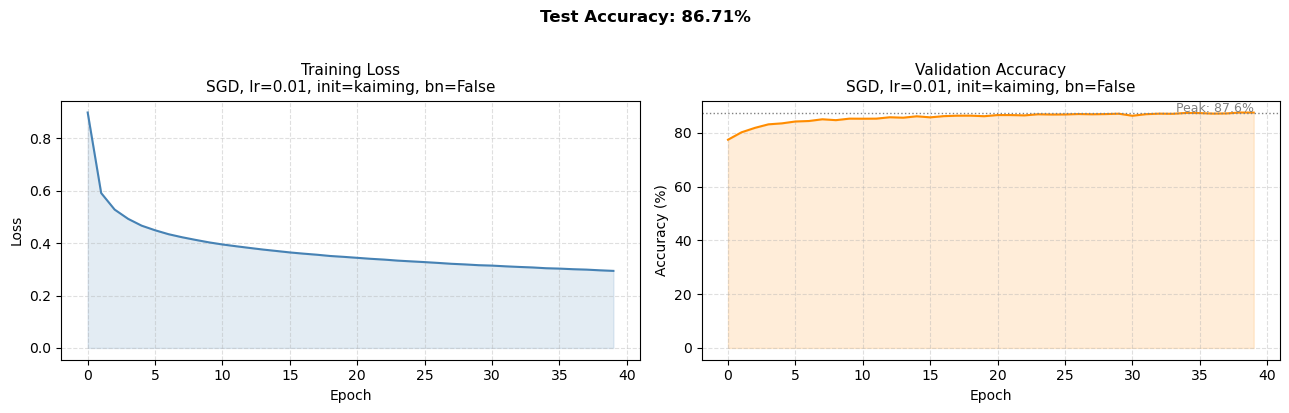

SGD lr=0.001 init=kaiming bn=False:   2%|▎         | 1/40 [00:06<03:54,  6.02s/it]

Epoch 00 | Train Loss: 1.7665 | Val Acc: 58.42%


SGD lr=0.001 init=kaiming bn=False:   5%|▌         | 2/40 [00:12<03:48,  6.01s/it]

Epoch 01 | Train Loss: 1.1130 | Val Acc: 67.35%


SGD lr=0.001 init=kaiming bn=False:   8%|▊         | 3/40 [00:18<03:42,  6.00s/it]

...

SGD lr=0.001 init=kaiming bn=False:  98%|█████████▊| 39/40 [03:50<00:05,  5.84s/it]

Epoch 38 | Train Loss: 0.4783 | Val Acc: 83.03%


SGD lr=0.001 init=kaiming bn=False: 100%|██████████| 40/40 [03:56<00:00,  5.90s/it]

Epoch 39 | Train Loss: 0.4751 | Val Acc: 83.20%


Test Accuracy: 82.20%


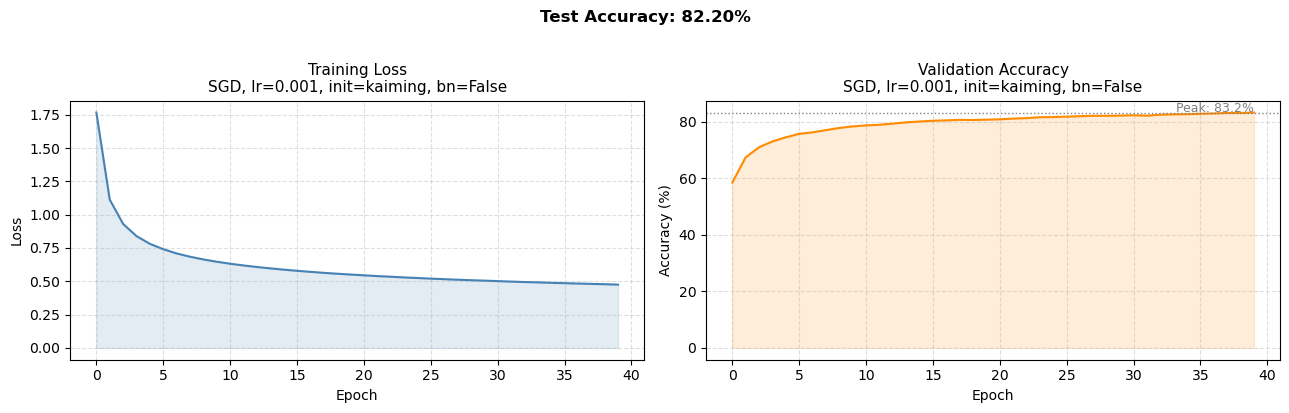

In [18]:
# SGD with different learning rates
model_sgd_01,  train_loss_sgd_01,  val_acc_sgd_01,  test_acc_sgd_01  = train_and_evaluate('SGD', lr=0.01)
model_sgd_001, train_loss_sgd_001, val_acc_sgd_001, test_acc_sgd_001 = train_and_evaluate('SGD', lr=0.001)

RMSprop lr=0.01 init=kaiming bn=False:   2%|▎         | 1/40 [00:05<03:53,  5.99s/it]

Epoch 00 | Train Loss: 72.9202 | Val Acc: 77.33%


RMSprop lr=0.01 init=kaiming bn=False:   5%|▌         | 2/40 [00:11<03:44,  5.91s/it]

Epoch 01 | Train Loss: 0.5782 | Val Acc: 79.21%


RMSprop lr=0.01 init=kaiming bn=False:   8%|▊         | 3/40 [00:17<03:35,  5.82s/it]

...

RMSprop lr=0.01 init=kaiming bn=False:  98%|█████████▊| 39/40 [03:48<00:05,  5.84s/it]

Epoch 38 | Train Loss: 0.2635 | Val Acc: 85.68%


RMSprop lr=0.01 init=kaiming bn=False: 100%|██████████| 40/40 [03:54<00:00,  5.87s/it]

Epoch 39 | Train Loss: 0.2807 | Val Acc: 87.28%


Test Accuracy: 86.73%


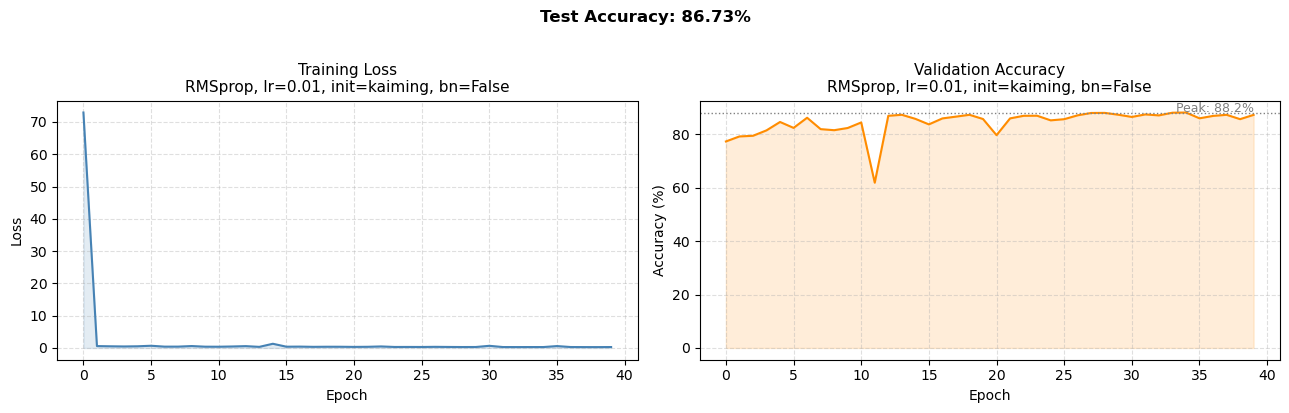

RMSprop lr=0.001 init=kaiming bn=False:   2%|▎         | 1/40 [00:05<03:51,  5.93s/it]

Epoch 00 | Train Loss: 1.0732 | Val Acc: 83.73%


RMSprop lr=0.001 init=kaiming bn=False:   5%|▌         | 2/40 [00:11<03:45,  5.93s/it]

Epoch 01 | Train Loss: 0.3899 | Val Acc: 78.53%


RMSprop lr=0.001 init=kaiming bn=False:   8%|▊         | 3/40 [00:18<03:43,  6.04s/it]

...

RMSprop lr=0.001 init=kaiming bn=False:  98%|█████████▊| 39/40 [03:44<00:05,  5.40s/it]

Epoch 38 | Train Loss: 0.0621 | Val Acc: 89.35%


RMSprop lr=0.001 init=kaiming bn=False: 100%|██████████| 40/40 [03:49<00:00,  5.74s/it]

Epoch 39 | Train Loss: 0.0362 | Val Acc: 90.05%


Test Accuracy: 89.18%


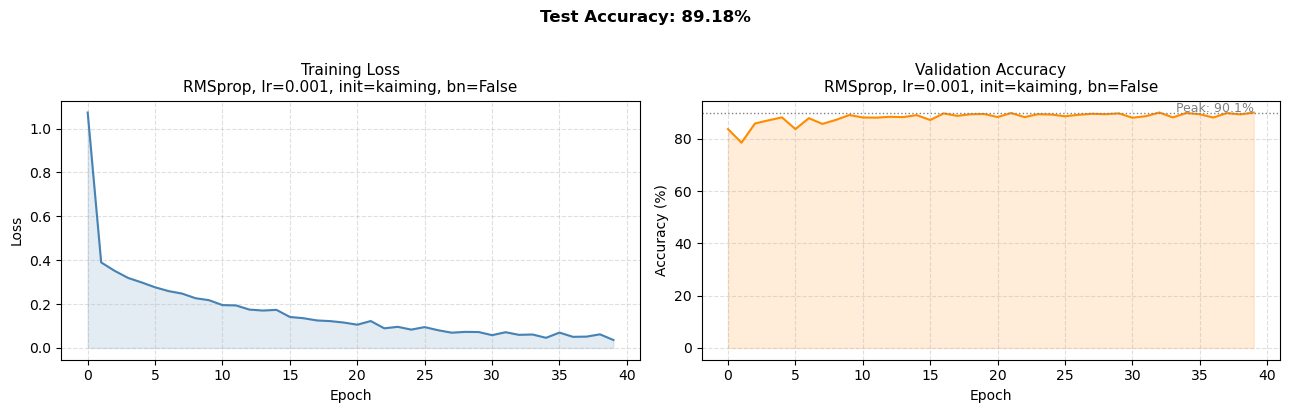

In [19]:
# RMSprop with different learning rates
model_rmsprop_01,  train_loss_rmsprop_01,  val_acc_rmsprop_01,  test_acc_rmsprop_01  = train_and_evaluate('RMSprop', lr=0.01)
model_rmsprop_001, train_loss_rmsprop_001, val_acc_rmsprop_001, test_acc_rmsprop_001 = train_and_evaluate('RMSprop', lr=0.001)

Adam lr=0.01 init=kaiming bn=False:   2%|▎         | 1/40 [00:05<03:22,  5.20s/it]

Epoch 00 | Train Loss: 1.2029 | Val Acc: 85.05%


Adam lr=0.01 init=kaiming bn=False:   5%|▌         | 2/40 [00:10<03:23,  5.36s/it]

Epoch 01 | Train Loss: 0.3759 | Val Acc: 86.10%


Adam lr=0.01 init=kaiming bn=False:   8%|▊         | 3/40 [00:16<03:24,  5.52s/it]

...

Adam lr=0.01 init=kaiming bn=False:  98%|█████████▊| 39/40 [03:36<00:05,  5.56s/it]

Epoch 38 | Train Loss: 0.2004 | Val Acc: 87.69%


Adam lr=0.01 init=kaiming bn=False: 100%|██████████| 40/40 [03:42<00:00,  5.55s/it]

Epoch 39 | Train Loss: 0.2056 | Val Acc: 88.11%


Test Accuracy: 87.47%


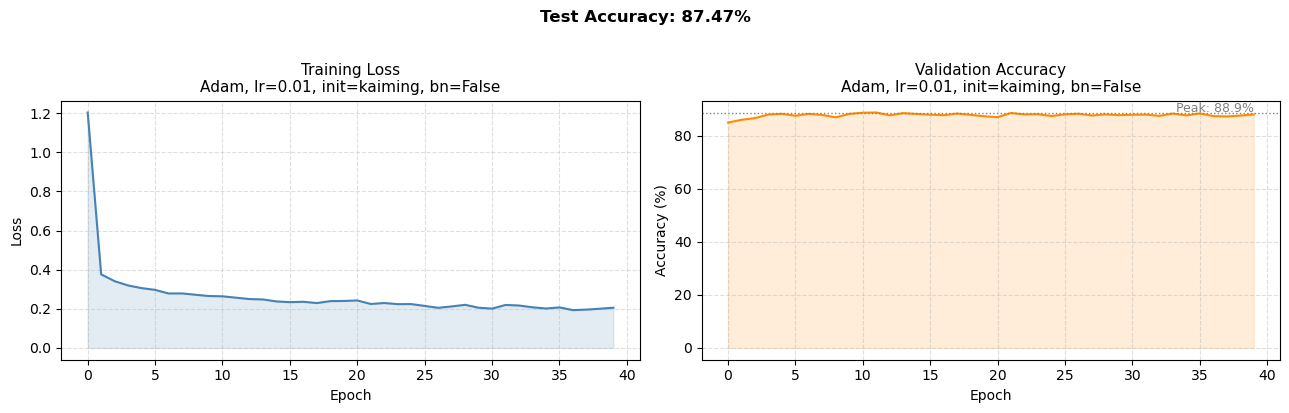

Adam lr=0.001 init=kaiming bn=False:   2%|▎         | 1/40 [00:05<03:31,  5.41s/it]

Epoch 00 | Train Loss: 0.5074 | Val Acc: 85.91%


Adam lr=0.001 init=kaiming bn=False:   5%|▌         | 2/40 [00:10<03:26,  5.43s/it]

Epoch 01 | Train Loss: 0.3396 | Val Acc: 87.25%


Adam lr=0.001 init=kaiming bn=False:   8%|▊         | 3/40 [00:16<03:22,  5.47s/it]

...

Adam lr=0.001 init=kaiming bn=False:  98%|█████████▊| 39/40 [03:37<00:05,  5.59s/it]

Epoch 38 | Train Loss: 0.0341 | Val Acc: 89.69%


Adam lr=0.001 init=kaiming bn=False: 100%|██████████| 40/40 [03:42<00:00,  5.57s/it]

Epoch 39 | Train Loss: 0.0323 | Val Acc: 89.95%


Test Accuracy: 89.30%


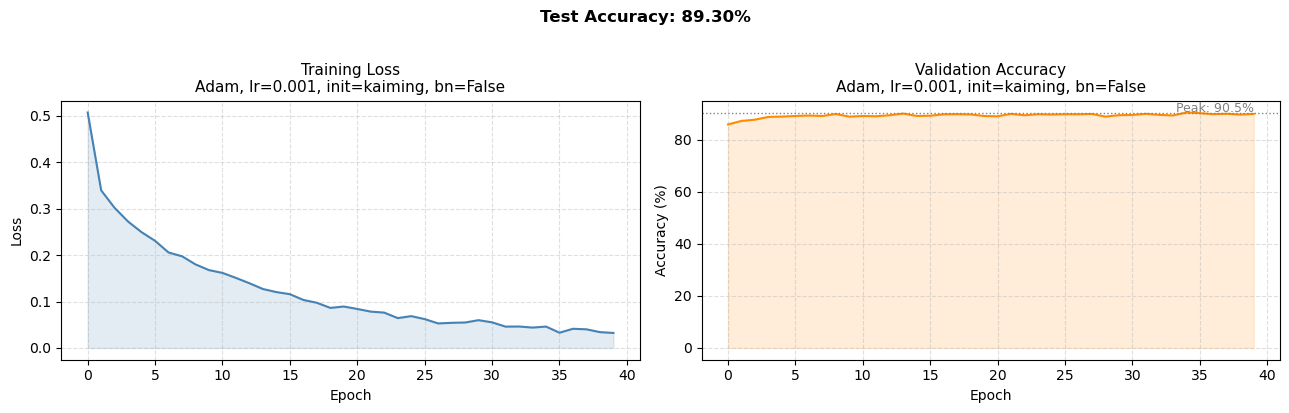

In [20]:
# Adam with different learning rates
model_adam_01,  train_loss_adam_01,  val_acc_adam_01,  test_acc_adam_01  = train_and_evaluate('Adam', lr=0.01)
model_adam_001, train_loss_adam_001, val_acc_adam_001, test_acc_adam_001 = train_and_evaluate('Adam', lr=0.001)

SGD lr=0.01 init=random_normal bn=False:   2%|▎         | 1/40 [00:05<03:39,  5.62s/it]

Epoch 00 | Train Loss: 1235.5437 | Val Acc: 75.70%


SGD lr=0.01 init=random_normal bn=False:   5%|▌         | 2/40 [00:11<03:37,  5.72s/it]

Epoch 01 | Train Loss: 74.4974 | Val Acc: 73.57%


SGD lr=0.01 init=random_normal bn=False:   8%|▊         | 3/40 [00:17<03:32,  5.75s/it]

...

SGD lr=0.01 init=random_normal bn=False:  98%|█████████▊| 39/40 [03:41<00:05,  5.73s/it]

Epoch 38 | Train Loss: 1.1067 | Val Acc: 68.53%


SGD lr=0.01 init=random_normal bn=False: 100%|██████████| 40/40 [03:47<00:00,  5.68s/it]

Epoch 39 | Train Loss: 1.0705 | Val Acc: 70.43%


Test Accuracy: 69.59%


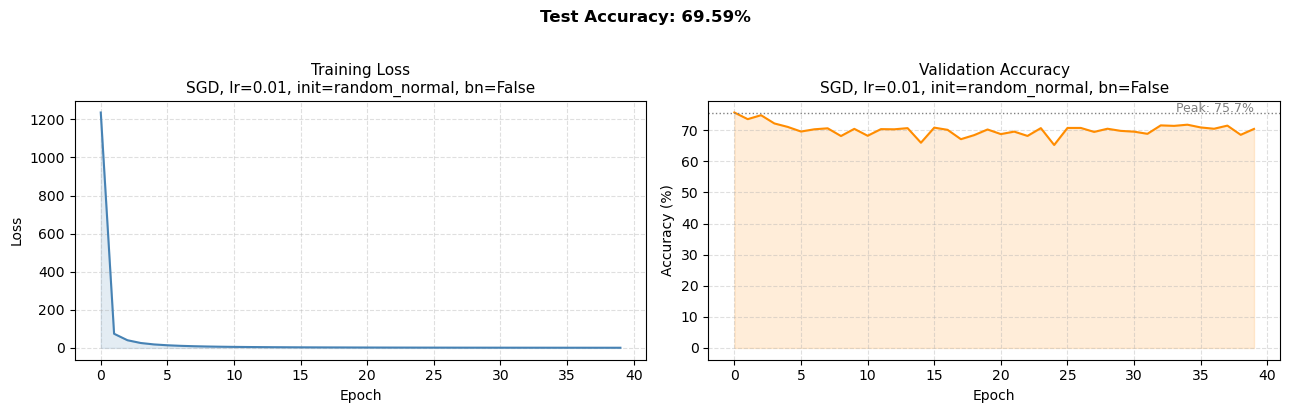

SGD lr=0.001 init=random_normal bn=False:   2%|▎         | 1/40 [00:05<03:43,  5.74s/it]

Epoch 00 | Train Loss: 1176.6885 | Val Acc: 74.19%


SGD lr=0.001 init=random_normal bn=False:   5%|▌         | 2/40 [00:11<03:30,  5.54s/it]

Epoch 01 | Train Loss: 493.7991 | Val Acc: 76.16%


SGD lr=0.001 init=random_normal bn=False:   8%|▊         | 3/40 [00:16<03:26,  5.59s/it]

...

SGD lr=0.001 init=random_normal bn=False:  98%|█████████▊| 39/40 [03:59<00:06,  6.42s/it]

Epoch 38 | Train Loss: 52.3667 | Val Acc: 81.66%


SGD lr=0.001 init=random_normal bn=False: 100%|██████████| 40/40 [04:05<00:00,  6.14s/it]

Epoch 39 | Train Loss: 50.2026 | Val Acc: 82.01%


Test Accuracy: 80.29%


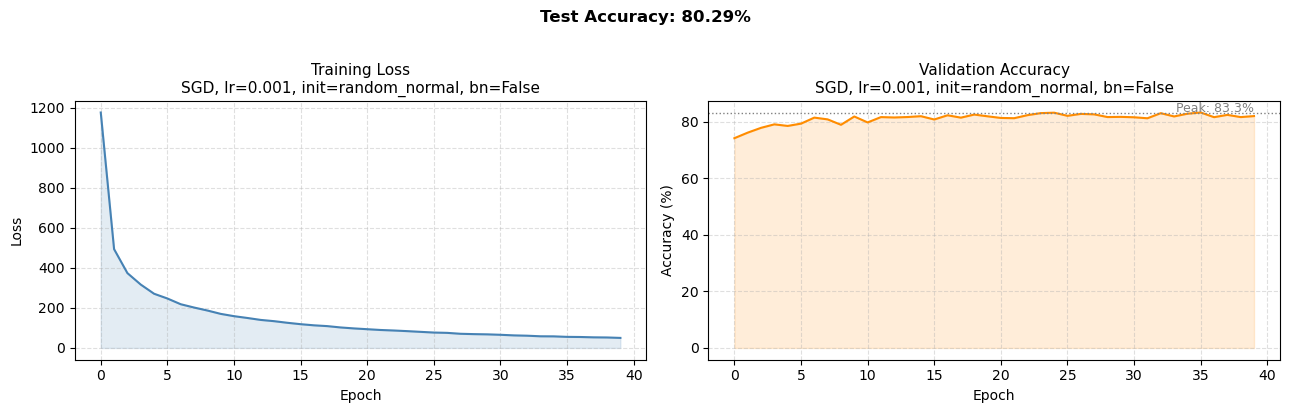

In [21]:
# Random Normal initialization with SGD
init_random,  tl_random,  val_acc_random,  test_acc_random  = train_and_evaluate('SGD', lr=0.01,  init_method='random_normal')
init_random1, tl_random1, val_acc_random1, test_acc_random1 = train_and_evaluate('SGD', lr=0.001, init_method='random_normal')

SGD lr=0.01 init=xavier bn=False:   2%|▎         | 1/40 [00:07<04:34,  7.04s/it]

Epoch 00 | Train Loss: 1.0316 | Val Acc: 75.66%


SGD lr=0.01 init=xavier bn=False:   5%|▌         | 2/40 [00:14<04:46,  7.54s/it]

Epoch 01 | Train Loss: 0.6437 | Val Acc: 79.13%


SGD lr=0.01 init=xavier bn=False:   8%|▊         | 3/40 [00:22<04:36,  7.46s/it]

...

SGD lr=0.01 init=xavier bn=False:  98%|█████████▊| 39/40 [04:32<00:07,  7.05s/it]

Epoch 38 | Train Loss: 0.3163 | Val Acc: 87.76%


SGD lr=0.01 init=xavier bn=False: 100%|██████████| 40/40 [04:39<00:00,  6.99s/it]

Epoch 39 | Train Loss: 0.3139 | Val Acc: 87.69%


Test Accuracy: 86.61%


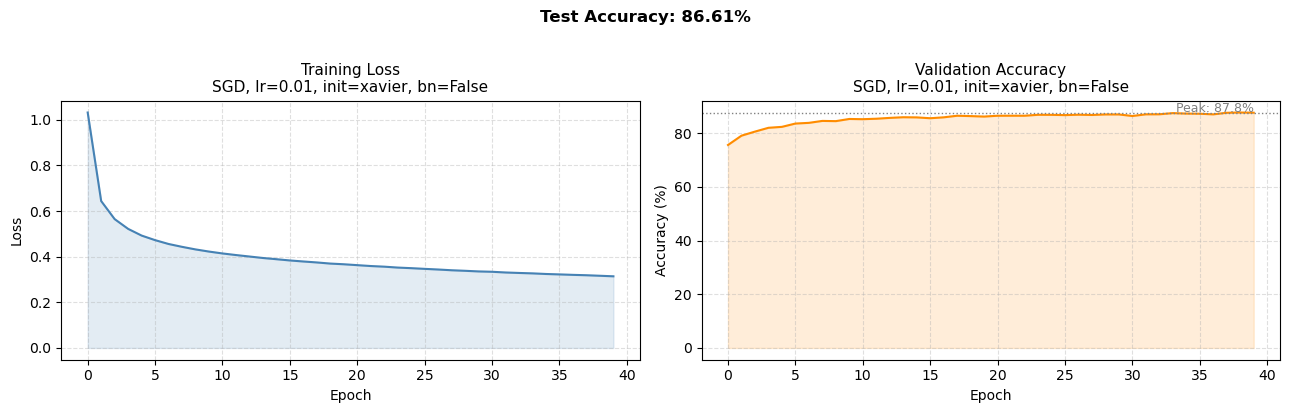

SGD lr=0.001 init=xavier bn=False:   2%|▎         | 1/40 [00:07<04:38,  7.14s/it]

Epoch 00 | Train Loss: 1.9525 | Val Acc: 52.54%


SGD lr=0.001 init=xavier bn=False:   5%|▌         | 2/40 [00:14<04:27,  7.04s/it]

Epoch 01 | Train Loss: 1.3708 | Val Acc: 64.07%


SGD lr=0.001 init=xavier bn=False:   8%|▊         | 3/40 [00:21<04:18,  7.00s/it]

...

SGD lr=0.001 init=xavier bn=False:  98%|█████████▊| 39/40 [04:19<00:05,  5.93s/it]

Epoch 38 | Train Loss: 0.5075 | Val Acc: 82.04%


SGD lr=0.001 init=xavier bn=False: 100%|██████████| 40/40 [04:25<00:00,  6.65s/it]

Epoch 39 | Train Loss: 0.5038 | Val Acc: 82.22%


Test Accuracy: 81.35%


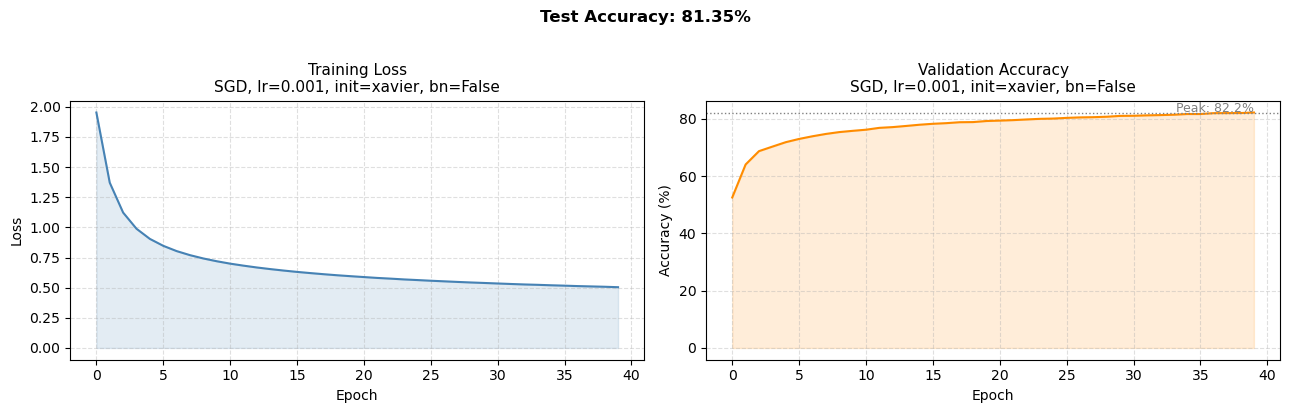

In [22]:
# Xavier initialization with SGD
init_xavier,  tl_xavier,  val_acc_xavier,  test_acc_xavier  = train_and_evaluate('SGD', lr=0.01,  init_method='xavier')
init_xavier1, tl_xavier1, val_acc_xavier1, test_acc_xavier1 = train_and_evaluate('SGD', lr=0.001, init_method='xavier')

SGD lr=0.01 init=kaiming bn=True:   2%|▎         | 1/40 [00:06<04:13,  6.50s/it]

Epoch 00 | Train Loss: 0.9851 | Val Acc: 77.40%


SGD lr=0.01 init=kaiming bn=True:   5%|▌         | 2/40 [00:12<03:59,  6.30s/it]

Epoch 01 | Train Loss: 0.6132 | Val Acc: 80.41%


SGD lr=0.01 init=kaiming bn=True:   8%|▊         | 3/40 [00:18<03:50,  6.23s/it]

...

SGD lr=0.01 init=kaiming bn=True:  98%|█████████▊| 39/40 [04:36<00:07,  7.07s/it]

Epoch 38 | Train Loss: 0.2799 | Val Acc: 88.17%


SGD lr=0.01 init=kaiming bn=True: 100%|██████████| 40/40 [04:43<00:00,  7.09s/it]

Epoch 39 | Train Loss: 0.2770 | Val Acc: 88.26%


Test Accuracy: 87.21%


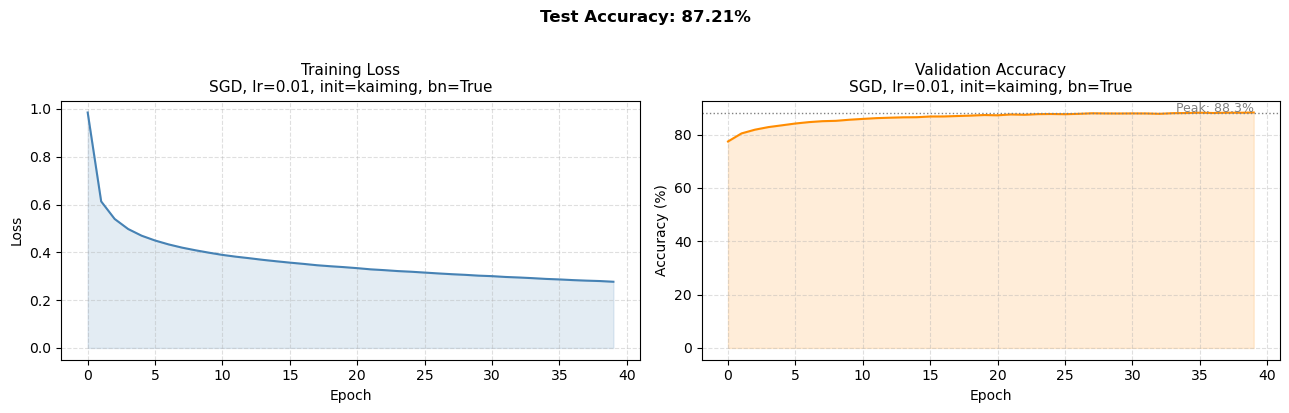

Adam lr=0.001 init=kaiming bn=True:   2%|▎         | 1/40 [00:07<05:01,  7.73s/it]

Epoch 00 | Train Loss: 0.4576 | Val Acc: 86.65%


Adam lr=0.001 init=kaiming bn=True:   5%|▌         | 2/40 [00:14<04:39,  7.36s/it]

Epoch 01 | Train Loss: 0.3119 | Val Acc: 88.59%


Adam lr=0.001 init=kaiming bn=True:   8%|▊         | 3/40 [00:21<04:27,  7.23s/it]

...

Adam lr=0.001 init=kaiming bn=True:  98%|█████████▊| 39/40 [04:46<00:07,  7.10s/it]

Epoch 38 | Train Loss: 0.0095 | Val Acc: 89.66%


Adam lr=0.001 init=kaiming bn=True: 100%|██████████| 40/40 [04:53<00:00,  7.34s/it]

Epoch 39 | Train Loss: 0.0137 | Val Acc: 89.83%


Test Accuracy: 89.47%


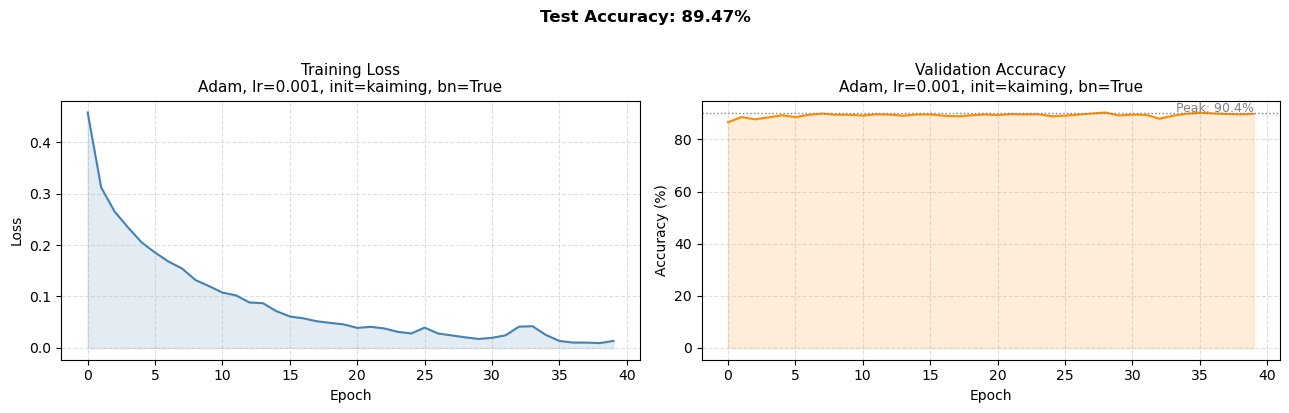

In [23]:
# Batch Normalization
model_sgd_bn,  train_loss_sgd_bn,  val_acc_sgd_bn,  test_acc_sgd_bn  = train_and_evaluate('SGD',  lr=0.01,  batch_norm=True)
model_adam_bn, train_loss_adam_bn, val_acc_adam_bn, test_acc_adam_bn = train_and_evaluate('Adam', lr=0.001, batch_norm=True)

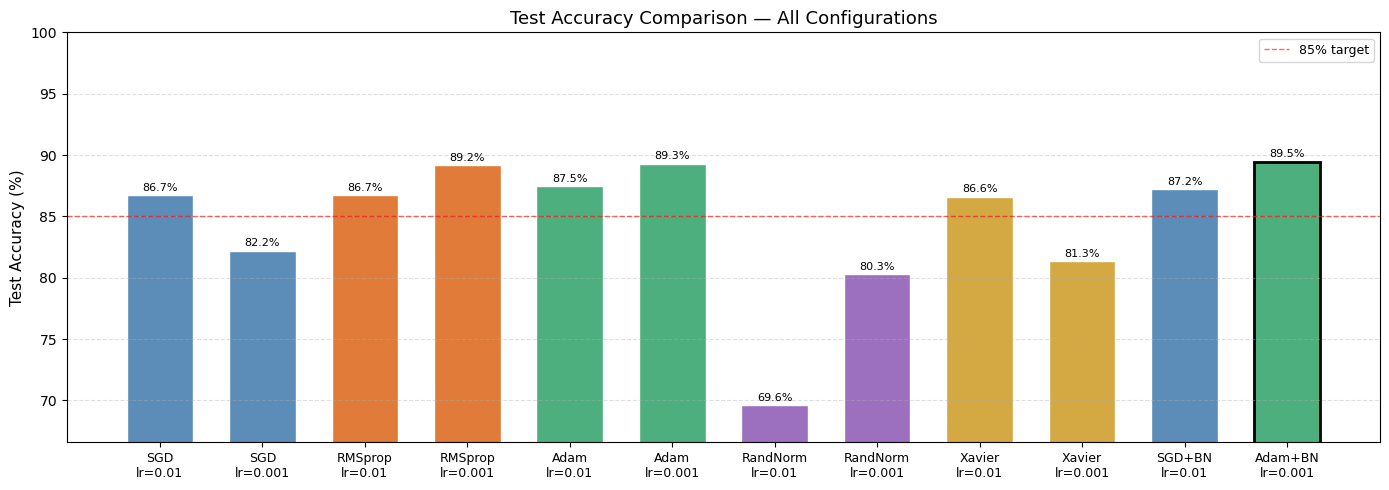


Best configuration : Adam+BN, lr=0.001
Best test accuracy : 89.47%


In [24]:
# ── Final comparison: test accuracy across all configurations ──
configs = [
    ('SGD\nlr=0.01',       test_acc_sgd_01),
    ('SGD\nlr=0.001',      test_acc_sgd_001),
    ('RMSprop\nlr=0.01',   test_acc_rmsprop_01),
    ('RMSprop\nlr=0.001',  test_acc_rmsprop_001),
    ('Adam\nlr=0.01',      test_acc_adam_01),
    ('Adam\nlr=0.001',     test_acc_adam_001),
    ('RandNorm\nlr=0.01',  test_acc_random),
    ('RandNorm\nlr=0.001', test_acc_random1),
    ('Xavier\nlr=0.01',    test_acc_xavier),
    ('Xavier\nlr=0.001',   test_acc_xavier1),
    ('SGD+BN\nlr=0.01',    test_acc_sgd_bn),
    ('Adam+BN\nlr=0.001',  test_acc_adam_bn),
]

labels, accs = zip(*configs)
colors = [
    '#5b8db8', '#5b8db8',   # SGD — blue
    '#e07b39', '#e07b39',   # RMSprop — orange
    '#4caf7d', '#4caf7d',   # Adam — green
    '#9c6fbf', '#9c6fbf',   # RandNorm — purple
    '#d4a843', '#d4a843',   # Xavier — amber
    '#5b8db8', '#4caf7d',   # BN variants
]

fig, ax = plt.subplots(figsize=(14, 5))
bars = ax.bar(range(len(labels)), accs, color=colors, edgecolor='white', width=0.65)

best_idx = accs.index(max(accs))
bars[best_idx].set_edgecolor('black')
bars[best_idx].set_linewidth(2)

ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, fontsize=9)
ax.set_ylabel('Test Accuracy (%)', fontsize=11)
ax.set_title('Test Accuracy Comparison — All Configurations', fontsize=13)
ax.set_ylim(min(accs) - 3, 100)
ax.axhline(y=85, color='red', linestyle='--', linewidth=1, alpha=0.6, label='85% target')
ax.legend(fontsize=9)
ax.grid(axis='y', linestyle='--', alpha=0.4)

for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.2,
            f'{acc:.1f}%', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

print(f'\nBest configuration : {labels[best_idx].replace(chr(10), ", ")}')
print(f'Best test accuracy : {max(accs):.2f}%')

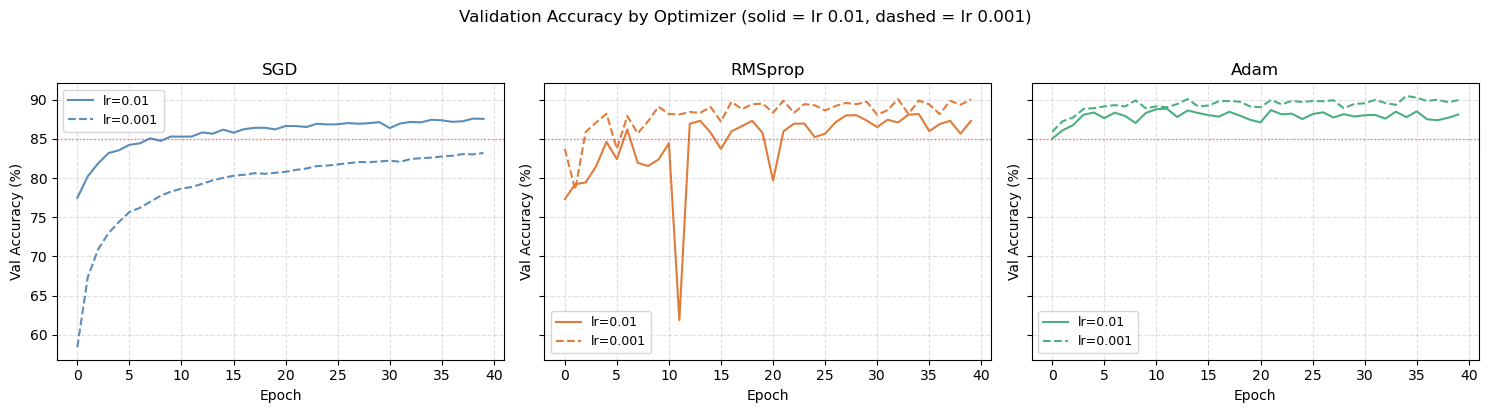

In [25]:
# ── Optimizer comparison: validation accuracy curves overlaid ──
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

# SGD
axes[0].plot(val_acc_sgd_01,  label='lr=0.01',  color='#5b8db8')
axes[0].plot(val_acc_sgd_001, label='lr=0.001', color='#5b8db8', linestyle='--')
axes[0].set_title('SGD', fontsize=12)

# RMSprop
axes[1].plot(val_acc_rmsprop_01,  label='lr=0.01',  color='#e07b39')
axes[1].plot(val_acc_rmsprop_001, label='lr=0.001', color='#e07b39', linestyle='--')
axes[1].set_title('RMSprop', fontsize=12)

# Adam
axes[2].plot(val_acc_adam_01,  label='lr=0.01',  color='#4caf7d')
axes[2].plot(val_acc_adam_001, label='lr=0.001', color='#4caf7d', linestyle='--')
axes[2].set_title('Adam', fontsize=12)

for ax in axes:
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Val Accuracy (%)')
    ax.legend(fontsize=9)
    ax.grid(True, linestyle='--', alpha=0.4)
    ax.axhline(y=85, color='red', linestyle=':', linewidth=1, alpha=0.5)

fig.suptitle('Validation Accuracy by Optimizer (solid = lr 0.01, dashed = lr 0.001)',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()